# Comparing Measured vs Predicted Binding and Expression Values
We want to be able to see how well our models are at predicting. We will compare the predicted values and measured values from the model from both training and testing.

## Extracting Wildtype Binding and Expression
To have our comparison to the wildtype values, we need to extract these. We'll find the average value for each binding and expression and plot them on the scatter plot.

In [2]:
import os
import pandas as pd

data_dir = "../../data/dms/original"
binding_df = pd.read_csv(os.path.join(data_dir, "binding_Kds.csv"), sep=',', header=0)
binding_df = binding_df.dropna(subset=['log10Ka']).reset_index(drop=True)
wildtype_b_df = binding_df[binding_df['variant_class'].str.contains('wildtype', case=False, na=False)]
wildtype_b_df = wildtype_b_df[['target', 'variant_class', 'aa_substitutions', 'log10Ka']].copy()
wildtype_b_df['mean_log10Ka'] = wildtype_b_df.groupby('target')['log10Ka'].transform('mean')
binding_wt = wildtype_b_df['mean_log10Ka'][8] 
binding_wt

10.792732335537766

In [3]:
expression_df = pd.read_csv(os.path.join(data_dir, "expression_meanFs.csv"), sep=',', header=0)
expression_df = expression_df.dropna(subset=['ML_meanF']).reset_index(drop=True)
wildtype_e_df = expression_df[expression_df['variant_class'].str.contains('wildtype', case=False, na=False)]
wildtype_e_df = wildtype_e_df[['target', 'variant_class', 'aa_substitutions', 'ML_meanF']].copy()
wildtype_e_df['mean_ML_meanF'] = wildtype_e_df.groupby('target')['ML_meanF'].transform('mean')
expression_wt = wildtype_e_df['mean_ML_meanF'][11]
expression_wt

10.29234282907662

## Model Predicted Values

In [4]:
import os
import sys
import tqdm
import time
import torch
import random
import datetime
import pandas as pd
import numpy as np
from typing import Union
from torch import nn
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, EsmModel

def load_model(saved_model_pth, device):
    saved_state = torch.load(saved_model_pth, map_location=device)

    model_state = saved_state['model_state_dict']
    optimizer_state = saved_state['optimizer_state_dict']

    epoch = saved_state['epoch']
    loss = saved_state['loss']

    print(f"Loaded in model from {saved_model_pth}, saved at epoch {epoch}, rmse loss {loss}")
    return model_state, optimizer_state, epoch, loss

class DMSDataset(Dataset):
    """ Binding or Expression DMS Dataset, single target. """
    
    def __init__(self, csv_file:str, result_tag:str):
        """
        Load from csv file into pandas:
        - sequence label ('labels'), 
        - 'sequence',
        - binding or expression target,
        """
        try:
            self.full_df = pd.read_csv(csv_file, sep=',', header=0)
            self.target = 'ACE2-binding_affinity' if 'binding' in result_tag else 'RBD_expression'
        except (FileNotFoundError, pd.errors.ParserError, Exception) as e:
            print(f"Error reading in .csv file: {csv_file}\n{e}", file=sys.stderr)
            sys.exit(1)

    def __len__(self) -> int:
        return len(self.full_df)

    def __getitem__(self, idx):
        # label, seq, target
        return self.full_df['label'][idx], self.full_df['sequence'][idx], self.full_df[self.target][idx]

/data/miniconda3/envs/spike_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### ESM-FCN

In [17]:
class FCN(nn.Module):
    """ Fully Connected Network """

    def __init__(self,
                 fcn_input_size,    # The number of input features
                 fcn_hidden_size,   # The number of features in hidden layer of FCN.
                 fcn_num_layers):   # The number of fcn layers  
        super().__init__()

        # Creating a list of layers for the FCN
        # Subsequent layers after 1st should be equal to hidden_size for input_size
        layers = []
        input_size = fcn_input_size

        for _ in range(fcn_num_layers):
            layers.append(nn.Linear(input_size, fcn_hidden_size))
            layers.append(nn.ReLU())
            input_size = fcn_hidden_size

        # FCN layers
        self.fcn = nn.Sequential(*layers)

        # FCN output layer 
        self.out = nn.Linear(fcn_hidden_size, 1)

    def forward(self, x):
        fcn_out = self.fcn(x)
        prediction = self.out(fcn_out).squeeze(1)  # [batch_size]
        
        return prediction

# ESM-FCN
class ESM_FCN(nn.Module):
    def __init__(self, esm, fcn):
        super().__init__()
        self.esm = esm
        self.fcn = fcn

    def forward(self, x):
        with torch.set_grad_enabled(self.training):  # Enable gradients, managed by model.eval() or model.train() in epoch_iteration
            esm_last_hidden_state = self.esm(**x).last_hidden_state # shape: [batch_size, sequence_length, embedding_dim]
            esm_cls_embedding = esm_last_hidden_state[:, 0, :]  # CLS token embedding (sequence-level representations), [batch_size, embedding_dim]
            output = self.fcn(esm_cls_embedding)
        return output
    
# MODEL RUNNING
def run_model(model, tokenizer, train_data_loader, test_data_loader, device: str, save_as: str, saved_model_pth:str=None):
    """ Run a model through train and test epochs. """

    model = model.to(device)
    loss_fn = nn.MSELoss(reduction='none').to(device)

    # Load saved model
    if saved_model_pth is not None and os.path.exists(saved_model_pth):
        model_state, _, _, _ = load_model(saved_model_pth, device)
        model.load_state_dict(model_state)

    # Running
    prediction_dict = {
        "seq_id": [],
        "predicted_value":[],
        "mode": []
    }
   
    # TRAIN
    train_data_iter = tqdm.tqdm(enumerate(train_data_loader),
                desc=f'Training data',
                total=len(train_data_loader),
                bar_format='{l_bar}{r_bar}')

    for batch, batch_data in train_data_iter:
        seq_ids, seqs, targets = batch_data
        targets = targets.to(device).float()
        tokenized_seqs = tokenizer(seqs, return_tensors="pt").to(device)
            
        model.train()
        preds = model(tokenized_seqs)
        batch_losses = loss_fn(preds, targets)
        batch_loss = sum(batch_losses)
        batch_loss.backward()

        for id, pred in zip(seq_ids, preds):
            prediction_dict["seq_id"].append(id)
            prediction_dict["predicted_value"].append(pred.item())
            prediction_dict["mode"].append("train")
        
    # TEST
    test_data_iter = tqdm.tqdm(enumerate(test_data_loader),
                desc=f'Testing data',
                total=len(test_data_loader),
                bar_format='{l_bar}{r_bar}')
    
    for batch, batch_data in test_data_iter:
        seq_ids, seqs, targets = batch_data
        targets = targets.to(device).float()
        tokenized_seqs = tokenizer(seqs, return_tensors="pt").to(device)

        model.eval()
        with torch.no_grad():
            preds = model(tokenized_seqs)
            batch_losses = loss_fn(preds, targets)

        for id, pred in zip(seq_ids, preds):
            prediction_dict["seq_id"].append(id)
            prediction_dict["predicted_value"].append(pred.item())
            prediction_dict["mode"].append("test")

    df = pd.DataFrame.from_dict(prediction_dict)
    df.to_csv(save_as, index=False)
    print(df)

# Run setup
batch_size = 64
num_workers = 4
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Data/results directories
result_tag = 'binding' # specify expression or binding
data_dir = '../../data/dms' 
results_dir = '../../results/run_results/esm_fcn'

run_dir_binding = os.path.join(results_dir, f'adam.lr1e-05.esm_fcn-DMS_OLD-binding-2024-12-04_17-54')
save_as_binding = os.path.join(run_dir_binding, f"all_predicted_values_best_saved.csv")
saved_model_pth_binding = os.path.join(run_dir_binding, "best_saved_model.pth")

run_dir_expression = os.path.join(results_dir, f'adam.lr1e-04.esm_fcn-DMS_OLD-expression-2024-12-05_04-15')
save_as_expression = os.path.join(run_dir_expression, f"all_predicted_values_best_saved.csv")
saved_model_pth_expression = os.path.join(run_dir_expression, "best_saved_model.pth")

# Create Dataset and DataLoader
torch.manual_seed(0)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

train_dataset = DMSDataset(os.path.join(data_dir, "mutation_combined_DMS_OLD_train.csv"), result_tag)
train_data_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    drop_last=False, 
    num_workers=num_workers, 
    worker_init_fn=seed_worker, 
    generator=torch.Generator().manual_seed(0), 
    pin_memory=True
)

test_dataset = DMSDataset(os.path.join(data_dir, "mutation_combined_DMS_OLD_test.csv"), result_tag)
test_data_loader = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    drop_last=False, 
    num_workers=num_workers, 
    worker_init_fn=seed_worker, 
    generator=torch.Generator().manual_seed(0), 
    pin_memory=True
)

# ESM input
esm_version = "facebook/esm2_t6_8M_UR50D" 
esm = EsmModel.from_pretrained(esm_version, cache_dir='../../../../model_downloads').to(device)
tokenizer = AutoTokenizer.from_pretrained(esm_version, cache_dir='../../../../model_downloads')

# FCN input
size = 320
fcn_input_size = size  
fcn_hidden_size = size
fcn_num_layers = 5
fcn = FCN(fcn_input_size, fcn_hidden_size, fcn_num_layers)

model = ESM_FCN(esm, fcn)

# Run
print("== BINDING ==")
run_model(model, tokenizer, train_data_loader, test_data_loader, device, save_as_binding, saved_model_pth_binding)
print("== EXPRESSION ==")
run_model(model, tokenizer, train_data_loader, test_data_loader, device, save_as_expression, saved_model_pth_expression)

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


== BINDING ==
Loaded in model from ../../results/run_results/esm_fcn/adam.lr1e-05.esm_fcn-DMS_OLD-binding-2024-12-04_17-54/best_saved_model.pth, saved at epoch 965, rmse loss 0.518519043711583


Testing data: 100%|| 322/322 [00:15<00:00, 21.17it/s]


                                      seq_id  predicted_value   mode
0                SARS-CoV-2-S19E_E141G_N157A         5.992850  train
1                SARS-CoV-2-T63F_Y178V_S184L         9.090733  train
2                     SARS-CoV-2-W106A_G146C         6.022359  train
3           SARS-CoV-2-A18C_R25V_L122T_P149R         6.108758  train
4                       SARS-CoV-2-D59W_P96S        10.125635  train
...                                      ...              ...    ...
102718      SARS-CoV-2-V11A_V32G_W106G_G146H         6.004795   test
102719  SARS-CoV-2-T3G_K48P_G83E_S147V_V173S         5.999191   test
102720                       SARS-CoV-2-K94H        10.770613   test
102721           SARS-CoV-2-T46L_S139T_F185Q         9.601976   test
102722      SARS-CoV-2-A14P_N58V_T140V_C150F         6.019128   test

[102723 rows x 3 columns]
== EXPRESSION ==
Loaded in model from ../../results/run_results/esm_fcn/adam.lr1e-04.esm_fcn-DMS_OLD-expression-2024-12-05_04-15/best_saved_model

Testing data: 100%|| 322/322 [00:15<00:00, 21.18it/s]


                                       seq_id  predicted_value   mode
0                  SARS-CoV-2-C6V_Q144E_F156G         9.245893  train
1              SARS-CoV-2-I28V_S41T_V77T_Q84R         7.942553  train
2                      SARS-CoV-2-N107T_G146Y         7.507504  train
3                         SARS-CoV-2-N4R_A81Q         9.617624  train
4       SARS-CoV-2-S41Y_F62L_Q79G_T100H_N130D         7.305279  train
...                                       ...              ...    ...
102718             SARS-CoV-2-S29E_L95Q_N120K         7.887379   test
102719             SARS-CoV-2-Y50T_N64S_N120P         7.815455   test
102720                   SARS-CoV-2-T15M_P96S         7.707346   test
102721      SARS-CoV-2-A22L_G101I_E135G_Q168I         7.775889   test
102722              SARS-CoV-2-T3S_D34L_A105F         7.511501   test

[102723 rows x 3 columns]


### ESM-GCN

In [30]:
from torch_geometric.nn import SAGEConv, global_mean_pool
from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader

class GraphSAGE(nn.Module):
    def __init__(self, input_channels, hidden_channels):
        super(GraphSAGE, self).__init__()
        self.conv1 = SAGEConv(input_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.output = nn.Linear(hidden_channels, 1)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index).relu()
        x = global_mean_pool(x, batch)
        output = self.output(x).squeeze(1)
        return output

class ESM_GCN(nn.Module):
    def __init__(self, esm, gcn):
        super().__init__()
        self.esm = esm
        self.gcn = gcn

    def forward(self, tokenized_seqs, targets):
        with torch.set_grad_enabled(self.training):  # Enable gradients, managed by model.eval() or model.train() in epoch_iteration
            esm_last_hidden_state = self.esm(**tokenized_seqs).last_hidden_state # shape: [batch_size, sequence_length, embedding_dim]
            esm_aa_embedding = esm_last_hidden_state[:, 1:-1, :] # Amino Acid-level representations, [batch_size, sequence_length-2, embedding_dim], excludes 1st and last tokens
            
            # Graph Construction
            graphs = []
            for embedding, target in zip(esm_aa_embedding, targets):
                edges = [(i, i+1) for i in range(embedding.size(0) - 1)]
                edge_index = torch.tensor(edges, dtype=torch.int64).t().contiguous()

                graphs.append(Data(
                    x=embedding, 
                    edge_index=edge_index,
                    y=torch.tensor([target], dtype=torch.float32)
                ))

            batch_graph = Batch.from_data_list(graphs).to(device)
            output = self.gcn(batch_graph.x, batch_graph.edge_index, batch_graph.batch)

        return output, batch_graph.y

# MODEL RUNNING
def run_model(model, tokenizer, train_data_loader, test_data_loader, device: str, save_as: str, saved_model_pth:str=None):
    """ Run a model through train and test epochs. """

    model = model.to(device)
    loss_fn = nn.MSELoss(reduction='none').to(device)

    # Load saved model
    if saved_model_pth is not None and os.path.exists(saved_model_pth):
        model_state, _, _, _ = load_model(saved_model_pth, device)
        model.load_state_dict(model_state)

    # Running
    prediction_dict = {
        "seq_id": [],
        "predicted_value":[],
        "mode": []
    }
   
    # TRAIN
    train_data_iter = tqdm.tqdm(enumerate(train_data_loader),
                desc=f'Training data',
                total=len(train_data_loader),
                bar_format='{l_bar}{r_bar}')

    for batch, batch_data in train_data_iter:
        seq_ids, seqs, targets = batch_data
        targets = targets.to(device).float()
        tokenized_seqs = tokenizer(seqs, return_tensors="pt").to(device)
            
        model.train()
        preds, y = model(tokenized_seqs, targets)
        batch_losses = loss_fn(preds, y)
        batch_loss = sum(batch_losses)
        batch_loss.backward()

        for id, pred in zip(seq_ids, preds):
            prediction_dict["seq_id"].append(id)
            prediction_dict["predicted_value"].append(pred.item())
            prediction_dict["mode"].append("train")
        
    # TEST
    test_data_iter = tqdm.tqdm(enumerate(test_data_loader),
                desc=f'Testing data',
                total=len(test_data_loader),
                bar_format='{l_bar}{r_bar}')
    
    for batch, batch_data in test_data_iter:
        seq_ids, seqs, targets = batch_data
        targets = targets.to(device).float()
        tokenized_seqs = tokenizer(seqs, return_tensors="pt").to(device)

        model.eval()
        with torch.no_grad():
            preds, y = model(tokenized_seqs, targets)
            batch_losses = loss_fn(preds, y)

        for id, pred in zip(seq_ids, preds):
            prediction_dict["seq_id"].append(id)
            prediction_dict["predicted_value"].append(pred.item())
            prediction_dict["mode"].append("test")

    df = pd.DataFrame.from_dict(prediction_dict)
    df.to_csv(save_as, index=False)
    print(df)

# Run setup
batch_size = 64
num_workers = 4
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Data/results directories
result_tag = 'binding' # specify expression or binding
data_dir = '../../data/dms' 
results_dir = '../../results/run_results/esm_gcn'

run_dir_binding = os.path.join(results_dir, f'adam.lr1e-05.esm_gcn-DMS_OLD-binding-2025-01-07_20-53')
save_as_binding = os.path.join(run_dir_binding, f"all_predicted_values_best_saved.csv")
saved_model_pth_binding = os.path.join(run_dir_binding, "best_saved_model.pth")

run_dir_expression = os.path.join(results_dir, f'adam.lr1e-05.esm_gcn-DMS_OLD-expression-2025-01-07_20-54')
save_as_expression = os.path.join(run_dir_expression, f"all_predicted_values_best_saved.csv")
saved_model_pth_expression = os.path.join(run_dir_expression, "best_saved_model.pth")

# Create Dataset and DataLoader
torch.manual_seed(0)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

train_dataset = DMSDataset(os.path.join(data_dir, "mutation_combined_DMS_OLD_train.csv"), result_tag)
train_data_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    drop_last=False, 
    num_workers=num_workers, 
    worker_init_fn=seed_worker, 
    generator=torch.Generator().manual_seed(0), 
    pin_memory=True
)

test_dataset = DMSDataset(os.path.join(data_dir, "mutation_combined_DMS_OLD_test.csv"), result_tag)
test_data_loader = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    drop_last=False, 
    num_workers=num_workers, 
    worker_init_fn=seed_worker, 
    generator=torch.Generator().manual_seed(0), 
    pin_memory=True
)

# ESM input
esm_version = "facebook/esm2_t6_8M_UR50D" 
esm = EsmModel.from_pretrained(esm_version, cache_dir='../../../../model_downloads').to(device)
tokenizer = AutoTokenizer.from_pretrained(esm_version, cache_dir='../../../../model_downloads')

# GraphSAGE input
size = 320
input_channels = size # Number of input channels (dimensions of the embeddings)
hidden_channels = size
gcn = GraphSAGE(input_channels, hidden_channels)

model = ESM_GCN(esm, gcn)

# Run
print("== BINDING ==")
run_model(model, tokenizer, train_data_loader, test_data_loader, device, save_as_binding, saved_model_pth_binding)
print("== EXPRESSION ==")
run_model(model, tokenizer, train_data_loader, test_data_loader, device, save_as_expression, saved_model_pth_expression)

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


== BINDING ==
Loaded in model from ../../results/run_results/esm_gcn/adam.lr1e-05.esm_gcn-DMS_OLD-binding-2025-01-07_20-53/best_saved_model.pth, saved at epoch 674, rmse loss 0.5200985174935644


Testing data: 100%|| 322/322 [00:17<00:00, 17.92it/s]


                                      seq_id  predicted_value   mode
0                SARS-CoV-2-S19E_E141G_N157A         5.994633  train
1                SARS-CoV-2-T63F_Y178V_S184L         9.189561  train
2                     SARS-CoV-2-W106A_G146C         6.009082  train
3           SARS-CoV-2-A18C_R25V_L122T_P149R         6.071588  train
4                       SARS-CoV-2-D59W_P96S        10.119879  train
...                                      ...              ...    ...
102718      SARS-CoV-2-V11A_V32G_W106G_G146H         6.156104   test
102719  SARS-CoV-2-T3G_K48P_G83E_S147V_V173S         6.044676   test
102720                       SARS-CoV-2-K94H        10.709883   test
102721           SARS-CoV-2-T46L_S139T_F185Q         9.715796   test
102722      SARS-CoV-2-A14P_N58V_T140V_C150F         5.997078   test

[102723 rows x 3 columns]
== EXPRESSION ==
Loaded in model from ../../results/run_results/esm_gcn/adam.lr1e-05.esm_gcn-DMS_OLD-expression-2025-01-07_20-54/best_saved_model

Testing data: 100%|| 322/322 [00:17<00:00, 17.93it/s]


                                       seq_id  predicted_value   mode
0                  SARS-CoV-2-C6V_Q144E_F156G         9.134587  train
1              SARS-CoV-2-I28V_S41T_V77T_Q84R         8.037154  train
2                      SARS-CoV-2-N107T_G146Y         7.564033  train
3                         SARS-CoV-2-N4R_A81Q         9.637535  train
4       SARS-CoV-2-S41Y_F62L_Q79G_T100H_N130D         7.322314  train
...                                       ...              ...    ...
102718             SARS-CoV-2-S29E_L95Q_N120K         7.930432   test
102719             SARS-CoV-2-Y50T_N64S_N120P         7.711224   test
102720                   SARS-CoV-2-T15M_P96S         7.622128   test
102721      SARS-CoV-2-A22L_G101I_E135G_Q168I         7.650521   test
102722              SARS-CoV-2-T3S_D34L_A105F         7.753603   test

[102723 rows x 3 columns]


## Figures - Scatter Plot
### ESM-FCN

-0.845641245692164
0.9877655231339716
                                 seq_id  predicted_value   mode  \
16      SARS-CoV-2-L5S_A18S_Y123K_S129T        10.841138  train   
48                SARS-CoV-2-L60M_K132L        10.845560  train   
51                      SARS-CoV-2-Y35F        10.792744  train   
114               SARS-CoV-2-Y35L_T201R        10.800141  train   
145               SARS-CoV-2-F44Y_L131I        10.821686  train   
...                                 ...              ...    ...   
102513              SARS-CoV-2-I2S_S41N        10.793863   test   
102516            SARS-CoV-2-N64Q_P197S        10.802460   test   
102521      SARS-CoV-2-C61N_Q168W_S200C        10.809632   test   
102678                   SARS-CoV-2-T3M        10.800537   test   
102694           SARS-CoV-2-K128N_K199M        10.828338   test   

        ACE2-binding_affinity  threshold  abs_diff  
16                  10.810000   1.081000  0.031138  
48                  10.890000   1.089000  0.044440 

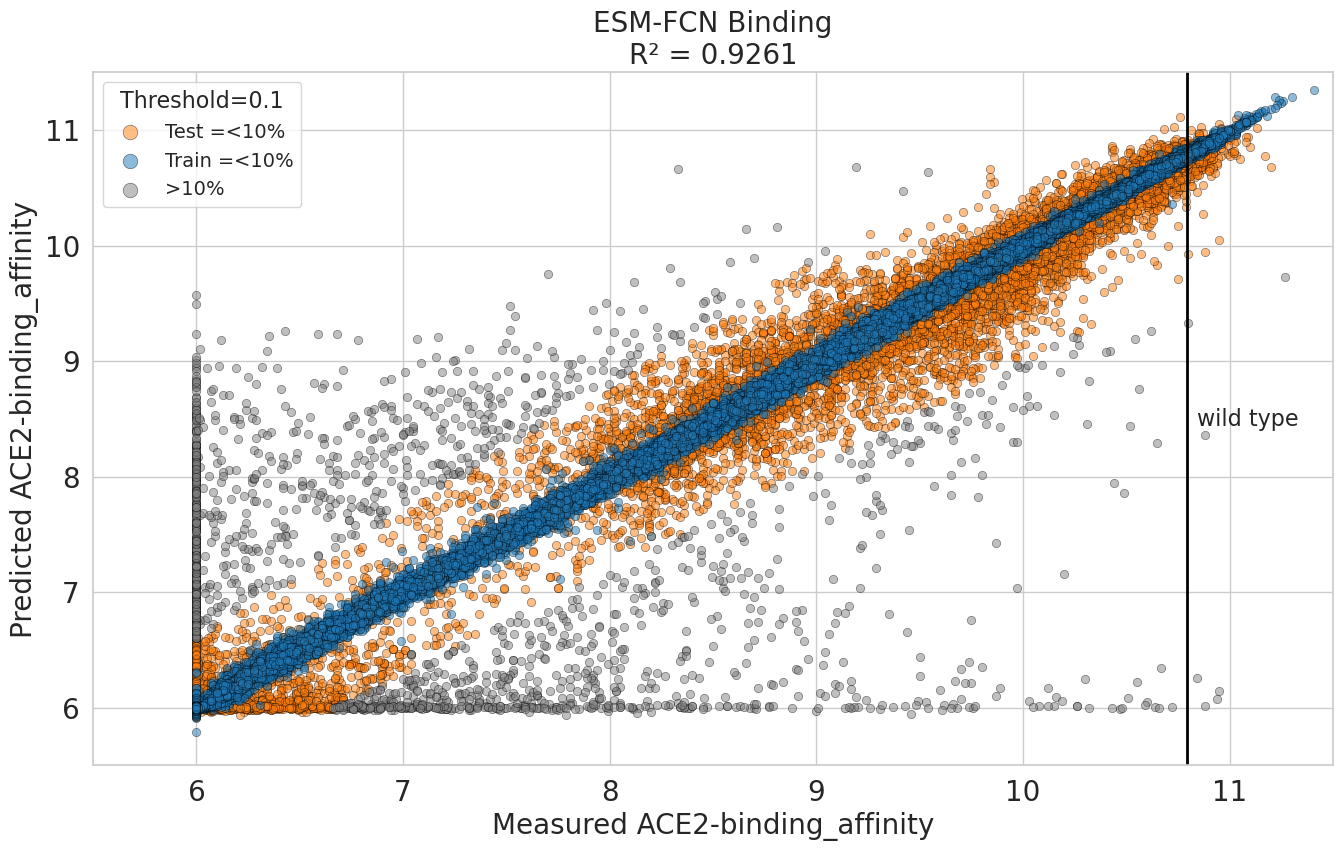

-0.2665091438536926
0.9257077118840804
                                  seq_id  predicted_value   mode  \
5             SARS-CoV-2-N40S_K56N_Y119K        10.429227  train   
11                      SARS-CoV-2-S129E        10.501081  train   
41                       SARS-CoV-2-R78V        10.467443  train   
45           SARS-CoV-2-T55K_K132H_S139T        10.419633  train   
75              SARS-CoV-2-I2F_I28M_C61D        10.642500  train   
...                                  ...              ...    ...   
102605  SARS-CoV-2-V11I_T55E_T148H_Y175L        10.383080   test   
102616        SARS-CoV-2-I28F_L60R_G146S        10.357234   test   
102672             SARS-CoV-2-T55A_K128R        10.393789   test   
102678            SARS-CoV-2-T100C_V153R        10.350938   test   
102710            SARS-CoV-2-F156E_T201P        10.328309   test   

        RBD_expression  threshold  abs_diff  
5            10.400000   1.040000  0.029227  
11           10.511667   1.051167  0.010585  
41    

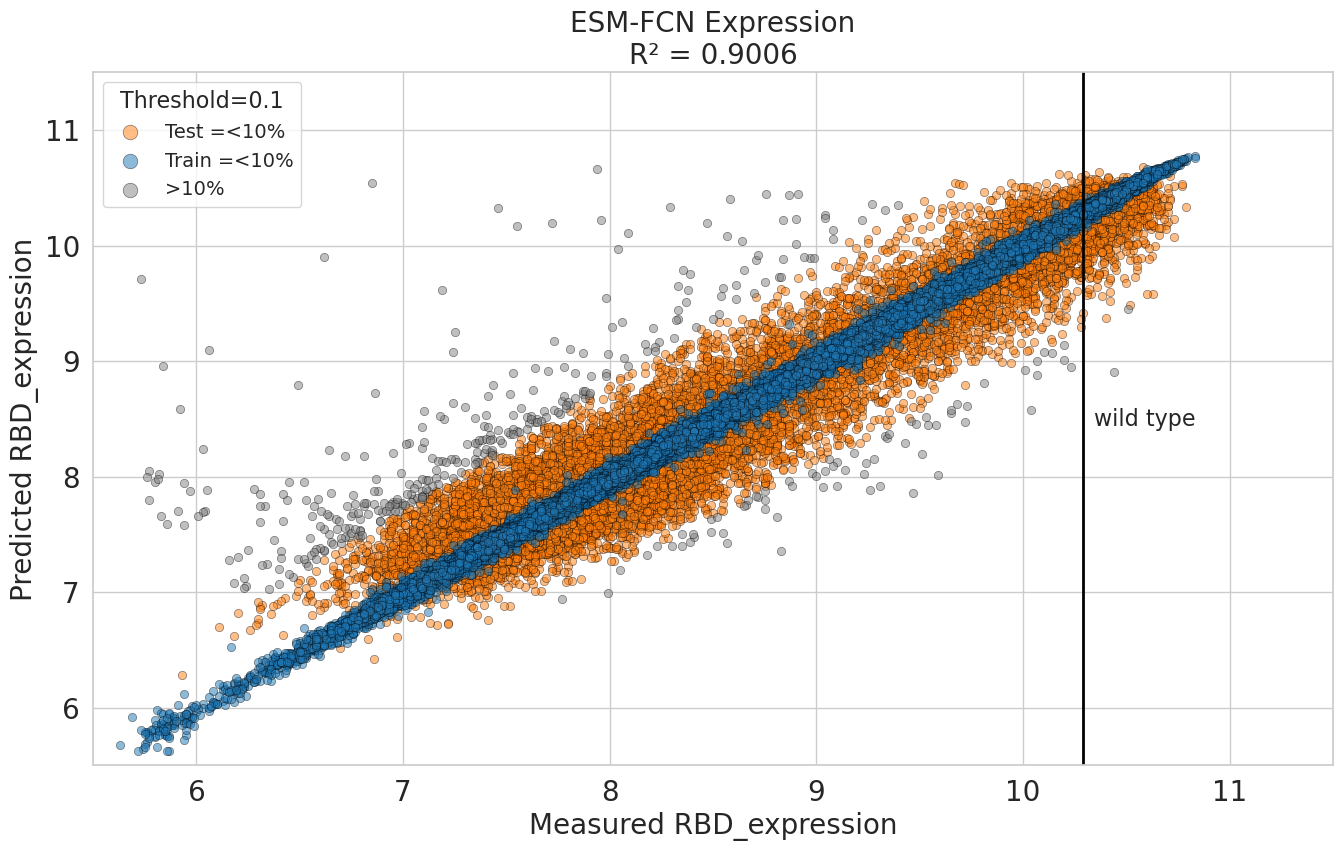

In [5]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

def plot_predicted_value_scatter_with_threshold(merged_df, measured_df_col, predicted_df_col, title, save_as, wt_loc, threshold_percent=10):
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(16, 9))
    ax = plt.gca()
    fontsize = 20

    # Calculate R² for test data
    test_all_df = merged_df[merged_df['mode'] == 'test']
    r2_value = r2_score(test_all_df[measured_df_col], test_all_df[predicted_df_col])

    # Calculate the threshold as 10% of measured values
    merged_df['threshold'] = merged_df[measured_df_col] * (threshold_percent/100)
    merged_df['abs_diff'] = np.abs(merged_df[measured_df_col] - merged_df[predicted_df_col])
    
    # Separate data based on the relative threshold
    within_threshold = merged_df[merged_df['abs_diff'] <= merged_df['threshold']]
    outside_threshold = merged_df[merged_df['abs_diff'] > merged_df['threshold']]

    test_outside_df = outside_threshold[outside_threshold['mode'] == 'test']
    r2_outside_value = r2_score(test_outside_df[measured_df_col], test_outside_df[predicted_df_col])
    print(r2_outside_value)

    test_inside_df = within_threshold[within_threshold['mode'] == 'test']
    r2_inside_value = r2_score(test_inside_df[measured_df_col], test_inside_df[predicted_df_col])
    print(r2_inside_value)

    high_freq_mutations = merged_df[merged_df[predicted_df_col] > wt_loc]
    high_freq_mutations.to_csv(save_as.replace('.pdf', '-beyond_wt.csv'), index=False)
    print(high_freq_mutations)

    # Plot train and test data within threshold
    test_df = within_threshold[within_threshold['mode'] == 'test']
    sns.scatterplot(
        x=test_df[measured_df_col],
        y=test_df[predicted_df_col],
        color="tab:orange",
        edgecolor="black",
        alpha=0.5,
        ax=ax,
        label="Test =<10%"
    )

    train_df = within_threshold[within_threshold['mode'] == 'train']
    sns.scatterplot(
        x=train_df[measured_df_col],
        y=train_df[predicted_df_col],
        color="tab:blue",
        edgecolor="black",
        alpha=0.5,
        ax=ax,
        label="Train =<10%"
    )

    # Plot train and test data outside threshold (greyed out)
    sns.scatterplot(
        data=outside_threshold,
        x=measured_df_col,
        y=predicted_df_col,
        color="gray",
        edgecolor="black",
        alpha=0.5,
        ax=ax,
        label=">10%"
    )

    # Add vertical line wildtype loc
    plt.axvline(x=wt_loc, color='black', linestyle='-', linewidth=2)
    plt.text(wt_loc+0.05, 8.4, 'wild type', 
            verticalalignment='bottom',
            fontsize=fontsize-4)

    plt.xlim(5.5, 11.5)
    plt.ylim(5.5, 11.5)
    plt.xlabel(f"Measured {measured_df_col}", fontsize=fontsize)
    plt.ylabel(f"Predicted {measured_df_col}", fontsize=fontsize)
    plt.xticks(fontsize=fontsize)
    plt.yticks(fontsize=fontsize)
    plt.title(f"{title}\nR² = {r2_value:.4f}", fontsize=fontsize)
    plt.legend(loc="upper left", title="Threshold=0.1", markerscale=1.75, fontsize=fontsize-6, title_fontsize=fontsize-4)
    plt.savefig(save_as, format='pdf')
    plt.savefig(save_as.replace('.pdf', '.png'), format='png')
    plt.show()

measured_df = pd.read_csv("../../data/dms/mutation_combined_DMS_OLD.csv", sep=',', header=0, usecols=['label', 'ACE2-binding_affinity'])
predicted_df = pd.read_csv("../../results/run_results/esm_fcn/adam.lr1e-05.esm_fcn-DMS_OLD-binding-2024-12-04_17-54/all_predicted_values_best_saved.csv", sep=',', header=0).reset_index(drop=True)
merged_df = pd.merge(
    predicted_df,
    measured_df,  
    left_on='seq_id', 
    right_on='label', 
    how='inner'
).drop('label', axis=1)
# all df are of length 102723
plot_predicted_value_scatter_with_threshold(merged_df, "ACE2-binding_affinity", "predicted_value", "ESM-FCN Binding", "../../results/plots/measured_vs_predicted/esm_fcn_binding-scatter.pdf", binding_wt)

measured_df = pd.read_csv("../../data/dms/mutation_combined_DMS_OLD.csv", sep=',', header=0, usecols=['label', 'RBD_expression'])
predicted_df = pd.read_csv("../../results/run_results/esm_fcn/adam.lr1e-04.esm_fcn-DMS_OLD-expression-2024-12-05_04-15/all_predicted_values_best_saved.csv", sep=',', header=0).reset_index(drop=True)
merged_df = pd.merge(
    predicted_df ,
    measured_df,  
    left_on='seq_id', 
    right_on='label', 
    how='inner'
).drop('label', axis=1)
plot_predicted_value_scatter_with_threshold(merged_df, "RBD_expression", "predicted_value", "ESM-FCN Expression", "../../results/plots/measured_vs_predicted/esm_fcn_expression-scatter.pdf", expression_wt)

### ESM-GCN
New double relu. Single relu version in progress if results end up better.

-0.7022222899509092
0.9877388397942654
                             seq_id  predicted_value   mode  \
48            SARS-CoV-2-L60M_K132L        10.871642  train   
145           SARS-CoV-2-F44Y_L131I        10.795346  train   
160          SARS-CoV-2-N120Q_T201N        10.813564  train   
210          SARS-CoV-2-L122K_E135K        10.819799  train   
265             SARS-CoV-2-I2L_T55Y        10.916457  train   
...                             ...              ...    ...   
102335   SARS-CoV-2-R16M_V37S_P197T        10.836244   test   
102503             SARS-CoV-2-Q163F        10.930343   test   
102516        SARS-CoV-2-N64Q_P197S        10.800061   test   
102521  SARS-CoV-2-C61N_Q168W_S200C        10.869431   test   
102678               SARS-CoV-2-T3M        10.793726   test   

        ACE2-binding_affinity  threshold  abs_diff  
48                  10.890000   1.089000  0.018358  
145                 10.870000   1.087000  0.074654  
160                 10.870000   1.087000  0.0

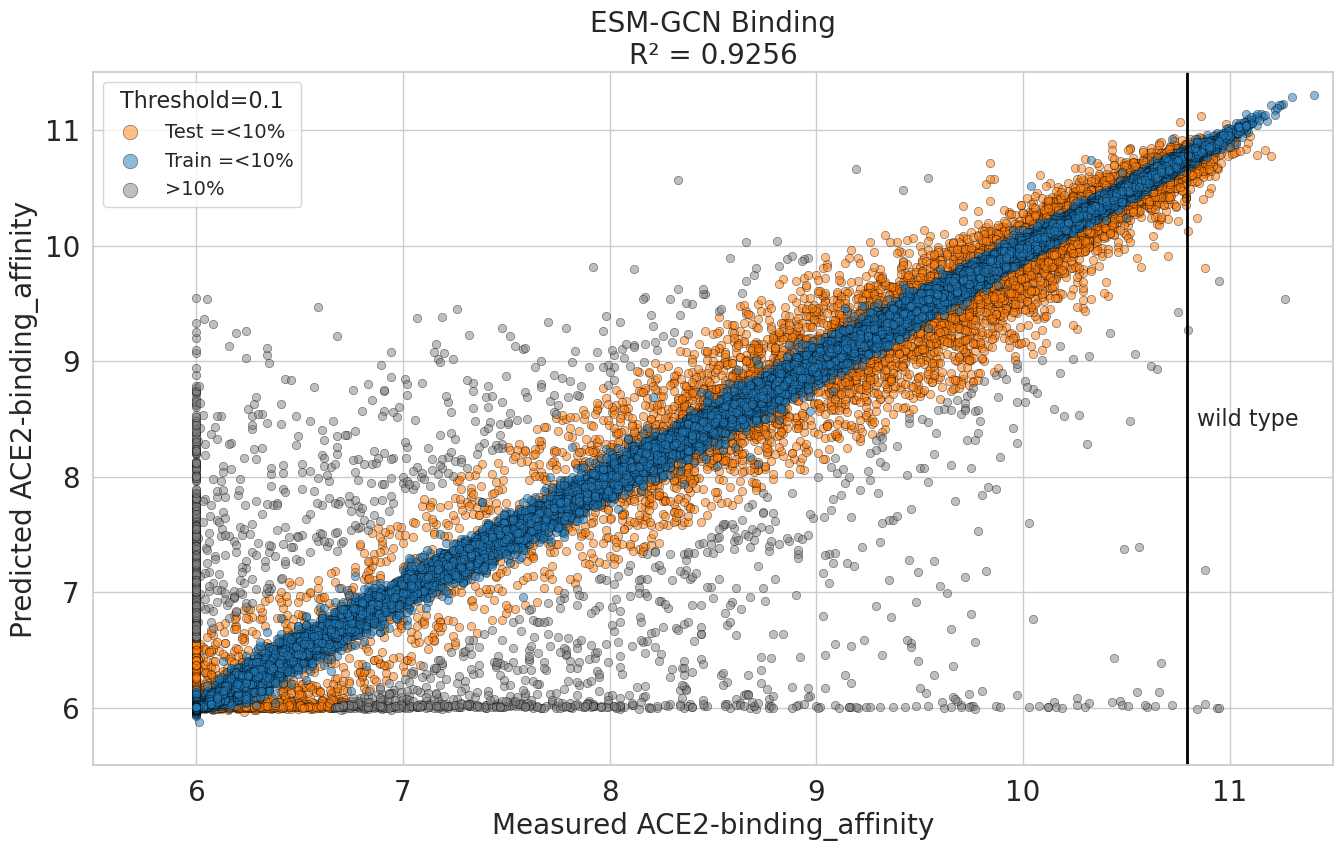

-0.16257395031767552
0.9248120169284488
                                  seq_id  predicted_value   mode  \
5             SARS-CoV-2-N40S_K56N_Y119K        10.375611  train   
11                      SARS-CoV-2-S129E        10.500302  train   
41                       SARS-CoV-2-R78V        10.450774  train   
45           SARS-CoV-2-T55K_K132H_S139T        10.396573  train   
75              SARS-CoV-2-I2F_I28M_C61D        10.642637  train   
...                                  ...              ...    ...   
102589        SARS-CoV-2-V37T_K48I_V153S        10.374444   test   
102600              SARS-CoV-2-A18S_N64T        10.303994   test   
102605  SARS-CoV-2-V11I_T55E_T148H_Y175L        10.332028   test   
102616        SARS-CoV-2-I28F_L60R_G146S        10.301366   test   
102710            SARS-CoV-2-F156E_T201P        10.446507   test   

        RBD_expression  threshold  abs_diff  
5            10.400000   1.040000  0.024389  
11           10.511667   1.051167  0.011364  
41   

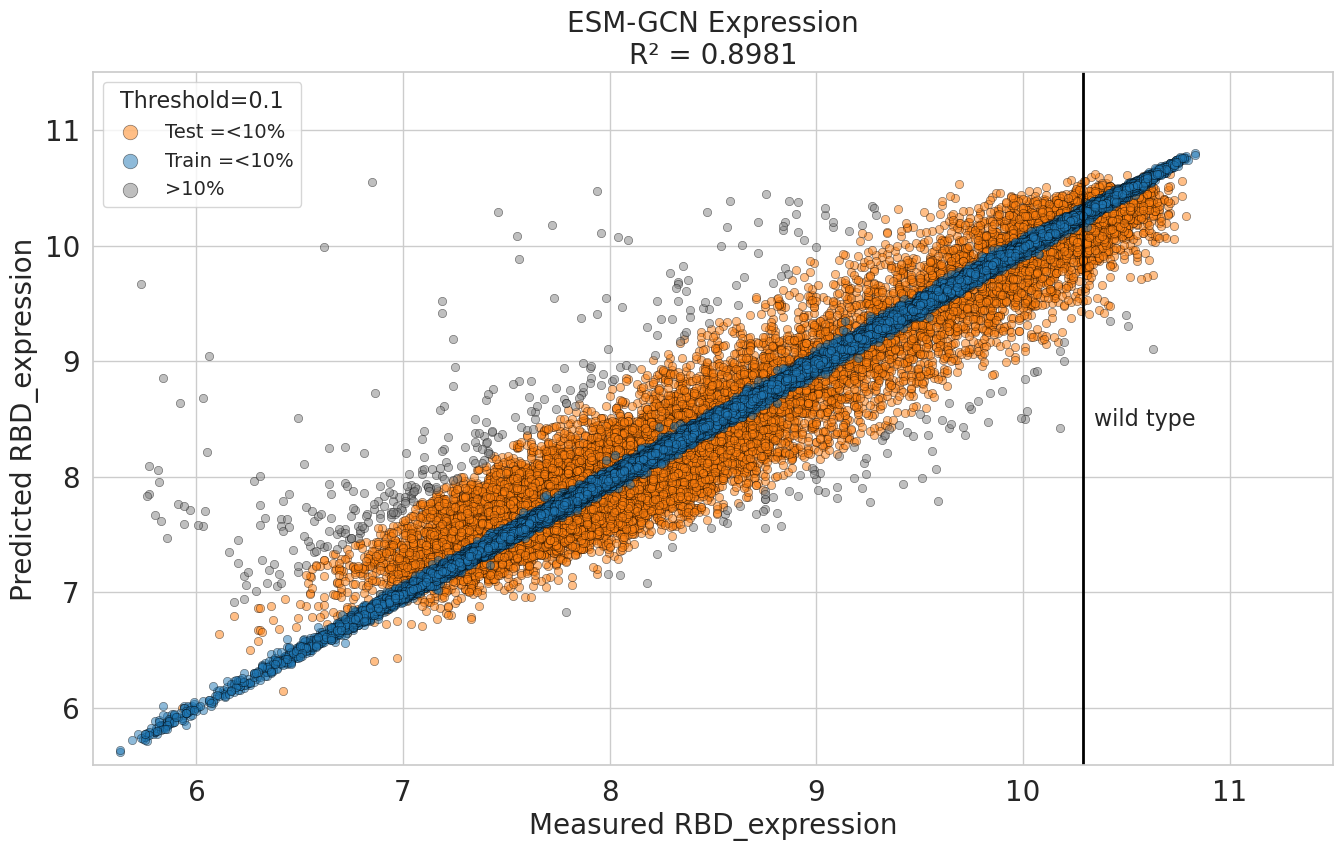

In [6]:
measured_df = pd.read_csv("../../data/dms/mutation_combined_DMS_OLD.csv", sep=',', header=0, usecols=['label', 'ACE2-binding_affinity'])
predicted_df = pd.read_csv("../../results/run_results/esm_gcn/adam.lr1e-05.esm_gcn-DMS_OLD-binding-2025-01-07_20-53/all_predicted_values_best_saved.csv", sep=',', header=0).reset_index(drop=True)
merged_df = pd.merge(
    predicted_df,
    measured_df,  
    left_on='seq_id', 
    right_on='label', 
    how='inner'
).drop('label', axis=1)
plot_predicted_value_scatter_with_threshold(merged_df, "ACE2-binding_affinity", "predicted_value", "ESM-GCN Binding", "../../results/plots/measured_vs_predicted/esm_gcn_binding-scatter.pdf", binding_wt)

measured_df = pd.read_csv("../../data/dms/mutation_combined_DMS_OLD.csv", sep=',', header=0, usecols=['label', 'RBD_expression'])
predicted_df = pd.read_csv("../../results/run_results/esm_gcn/adam.lr1e-05.esm_gcn-DMS_OLD-expression-2025-01-07_20-54/all_predicted_values_best_saved.csv", sep=',', header=0).reset_index(drop=True)
merged_df = pd.merge(
    predicted_df ,
    measured_df,  
    left_on='seq_id', 
    right_on='label', 
    how='inner'
).drop('label', axis=1)
plot_predicted_value_scatter_with_threshold(merged_df, "RBD_expression", "predicted_value", "ESM-GCN Expression", "../../results/plots/measured_vs_predicted/esm_gcn_expression-scatter.pdf", expression_wt)

---

## Looking at Mutations Beyond Wild Type
We extracted the values that contained expression or binding values beyond the wild type values. Let's take a deeper look into the mutations for these. 

### ESM-FCN
Binding data first:

In [261]:
b_beyond_wt_df = pd.read_csv("../../results/plots/measured_vs_predicted/esm_fcn_binding-scatter-beyond_wt.csv", sep=',', header=0, usecols=['seq_id', 'predicted_value', 'mode', 'ACE2-binding_affinity'])
b_beyond_wt_df['target'] = b_beyond_wt_df['seq_id'].str.rsplit('-', n=1).str[0]
b_beyond_wt_df['aa_substitutions'] = b_beyond_wt_df['seq_id'].str.rsplit('-', n=1).str[1].str.rsplit('_')
b_beyond_wt_df = b_beyond_wt_df.explode('aa_substitutions')
b_beyond_wt_df

,seq_id,predicted_value,mode,ACE2-binding_affinity,target,aa_substitutions
0,SARS-CoV-2-L5S_A18S_Y123K_S129T,10.841138,train,10.810000,SARS-CoV-2,L5S
0,SARS-CoV-2-L5S_A18S_Y123K_S129T,10.841138,train,10.810000,SARS-CoV-2,A18S
0,SARS-CoV-2-L5S_A18S_Y123K_S129T,10.841138,train,10.810000,SARS-CoV-2,Y123K
0,SARS-CoV-2-L5S_A18S_Y123K_S129T,10.841138,train,10.810000,SARS-CoV-2,S129T
1,SARS-CoV-2-L60M_K132L,10.845560,train,10.890000,SARS-CoV-2,L60M
...,...,...,...,...,...,...
1959,SARS-CoV-2-C61N_Q168W_S200C,10.809632,test,10.790000,SARS-CoV-2,Q168W
1959,SARS-CoV-2-C61N_Q168W_S200C,10.809632,test,10.790000,SARS-CoV-2,S200C
1960,SARS-CoV-2-T3M,10.800537,test,10.771818,SARS-CoV-2,T3M
1961,SARS-CoV-2-K128N_K199M,10.828338,test,10.800000,SARS-CoV-2,K128N


Of the spike protein's 1273 amino acid residues, receptor binding domain is located between 319–541 (223 aa long). So we'll add 318 for the mutation site (the sites were not 0-indexed; site 1 should be site 319), and rename to RBD mutation site for clarification.

In [262]:
b_beyond_wt_df['RBD_mutation_site'] = b_beyond_wt_df['aa_substitutions'].str.extract(r'(\d+)').astype(int) + 318 # Extract numeric site, RBD site
b_beyond_wt_df['original_aa'] = b_beyond_wt_df['aa_substitutions'].str[0]
b_beyond_wt_df['new_aa'] = b_beyond_wt_df['aa_substitutions'].str[-1]
b_beyond_wt_df['aa_sub'] = b_beyond_wt_df['original_aa'] + ">" + b_beyond_wt_df['new_aa']
print(len(b_beyond_wt_df))
b_beyond_wt_df.head(10)

4015


,seq_id,predicted_value,mode,ACE2-binding_affinity,target,aa_substitutions,RBD_mutation_site,original_aa,new_aa,aa_sub
0,SARS-CoV-2-L5S_A18S_Y123K_S129T,10.841138,train,10.810000,SARS-CoV-2,L5S,323,L,S,L>S
0,SARS-CoV-2-L5S_A18S_Y123K_S129T,10.841138,train,10.810000,SARS-CoV-2,A18S,336,A,S,A>S
0,SARS-CoV-2-L5S_A18S_Y123K_S129T,10.841138,train,10.810000,SARS-CoV-2,Y123K,441,Y,K,Y>K
0,SARS-CoV-2-L5S_A18S_Y123K_S129T,10.841138,train,10.810000,SARS-CoV-2,S129T,447,S,T,S>T
1,SARS-CoV-2-L60M_K132L,10.845560,train,10.890000,SARS-CoV-2,L60M,378,L,M,L>M
1,SARS-CoV-2-L60M_K132L,10.845560,train,10.890000,SARS-CoV-2,K132L,450,K,L,K>L
2,SARS-CoV-2-Y35F,10.792744,train,10.765833,SARS-CoV-2,Y35F,353,Y,F,Y>F
3,SARS-CoV-2-Y35L_T201R,10.800141,train,10.830000,SARS-CoV-2,Y35L,353,Y,L,Y>L
3,SARS-CoV-2-Y35L_T201R,10.800141,train,10.830000,SARS-CoV-2,T201R,519,T,R,T>R
4,SARS-CoV-2-F44Y_L131I,10.821686,train,10.870000,SARS-CoV-2,F44Y,362,F,Y,F>Y


Each site has only 1 original amino acid per. We can use this to our advantage in a figure! Perhaps a stacked histogram or heatmap?

In [263]:
original_aa_dict = b_beyond_wt_df.groupby('RBD_mutation_site')['original_aa'].apply(lambda x: list(set(x))).to_dict()
print(f"Original amino acids per site: {original_aa_dict}\n")

new_aa_dict = b_beyond_wt_df.groupby('RBD_mutation_site')['new_aa'].apply(lambda x: list(set(x))).to_dict()
unique_new_aa = sorted(list(set(value for values in new_aa_dict.values() for value in values)))
print(f"{len(unique_new_aa)} amino acids available: {unique_new_aa}\n")

Original amino acids per site: {319: ['N'], 320: ['I'], 321: ['T'], 322: ['N'], 323: ['L'], 324: ['C'], 325: ['P'], 326: ['F'], 327: ['G'], 328: ['E'], 329: ['V'], 331: ['N'], 332: ['A'], 333: ['T'], 334: ['R'], 335: ['F'], 336: ['A'], 337: ['S'], 339: ['Y'], 340: ['A'], 342: ['N'], 343: ['R'], 344: ['K'], 345: ['R'], 346: ['I'], 347: ['S'], 348: ['N'], 350: ['V'], 351: ['A'], 352: ['D'], 353: ['Y'], 354: ['S'], 355: ['V'], 356: ['L'], 357: ['Y'], 358: ['N'], 359: ['S'], 360: ['A'], 361: ['S'], 362: ['F'], 363: ['S'], 364: ['T'], 365: ['F'], 366: ['K'], 368: ['Y'], 369: ['G'], 370: ['V'], 371: ['S'], 372: ['P'], 373: ['T'], 374: ['K'], 375: ['L'], 376: ['N'], 377: ['D'], 378: ['L'], 379: ['C'], 380: ['F'], 381: ['T'], 382: ['N'], 383: ['V'], 384: ['Y'], 390: ['I'], 393: ['D'], 394: ['E'], 395: ['V'], 396: ['R'], 398: ['I'], 399: ['A'], 400: ['P'], 401: ['G'], 402: ['Q'], 403: ['T'], 405: ['K'], 407: ['A'], 408: ['D'], 409: ['Y'], 412: ['K'], 413: ['L'], 414: ['P'], 415: ['D'], 416: ['D

Now let's check to see how many total mutations occur at the site, and the breakdown of each amino acid count at each RBD mutation site. Then we'll sort each binding site by the amino acid mutation that occurs the most to least.

In [264]:
from collections import Counter

new_aa_total_ct_dict = b_beyond_wt_df.groupby('RBD_mutation_site')['new_aa'].count().to_dict()
print(new_aa_total_ct_dict)

new_aa_ct_dict = b_beyond_wt_df.groupby('RBD_mutation_site')['new_aa'].apply(lambda x: list(Counter(x).items())).to_dict()
sorted_new_aa_ct_dict = {k: sorted(v, key=lambda x: x[1], reverse=True) for k, v in new_aa_ct_dict.items()}
print(sorted_new_aa_ct_dict )

{319: 38, 320: 108, 321: 52, 322: 31, 323: 114, 324: 2, 325: 21, 326: 8, 327: 71, 328: 7, 329: 6, 331: 1, 332: 1, 333: 14, 334: 73, 335: 1, 336: 18, 337: 2, 339: 1, 340: 6, 342: 19, 343: 1, 344: 18, 345: 33, 346: 32, 347: 19, 348: 1, 350: 22, 351: 14, 352: 2, 353: 48, 354: 47, 355: 181, 356: 4, 357: 73, 358: 20, 359: 12, 360: 35, 361: 66, 362: 13, 363: 9, 364: 12, 365: 2, 366: 25, 368: 6, 369: 14, 370: 7, 371: 30, 372: 61, 373: 99, 374: 55, 375: 1, 376: 14, 377: 26, 378: 46, 379: 16, 380: 26, 381: 20, 382: 68, 383: 3, 384: 7, 390: 6, 393: 3, 394: 3, 395: 3, 396: 5, 398: 1, 399: 1, 400: 3, 401: 17, 402: 24, 403: 49, 405: 4, 407: 3, 408: 23, 409: 11, 412: 2, 413: 8, 414: 1, 415: 49, 416: 29, 417: 3, 418: 64, 419: 1, 421: 1, 422: 23, 423: 4, 424: 1, 425: 1, 427: 5, 428: 35, 429: 15, 431: 3, 432: 18, 433: 12, 434: 2, 438: 37, 439: 3, 440: 173, 441: 25, 443: 1, 445: 2, 446: 56, 447: 68, 448: 64, 449: 5, 450: 25, 451: 1, 452: 9, 453: 2, 454: 4, 456: 26, 457: 16, 458: 35, 459: 28, 460: 7, 461

Let's take a look at the RBD sites and the mutations occuring there:

In [265]:
data = []
for site in sorted(new_aa_total_ct_dict.keys()):
    total = new_aa_total_ct_dict[site]
    mutations = sorted_new_aa_ct_dict[site]
    mutation_str = ', '.join([f"{aa}({count})" for aa, count in mutations])
    data.append({
        'RBD Site': site,
        'Original Amino Acid': original_aa_dict[site][0],
        'Total Mutations': total,
        'Amino Acid Substitutions (Count)': mutation_str
    })

df = pd.DataFrame(data)
print(df.to_string(index=False))

 RBD Site Original Amino Acid  Total Mutations                                                                                          Amino Acid Substitutions (Count)
      319                   N               38                S(6), L(4), Q(3), K(3), T(3), P(2), E(2), R(2), G(2), D(2), V(2), Y(1), C(1), F(1), I(1), M(1), A(1), H(1)
      320                   I              108       L(12), S(12), R(10), D(9), E(8), V(8), P(7), M(7), T(6), K(5), H(5), F(4), N(4), A(4), Y(2), C(2), Q(1), G(1), W(1)
      321                   T               52                           S(10), P(7), D(4), M(4), L(3), H(3), G(3), N(3), K(3), Y(2), R(2), W(2), I(2), A(2), V(1), Q(1)
      322                   N               31                                                                      S(8), K(4), T(4), Q(4), A(3), D(2), E(2), G(2), R(2)
      323                   L              114            P(14), S(13), Q(13), E(10), W(9), T(8), V(7), F(5), R(5), A(4), N(4), D(4), M(4), K(3), I(3), Y(3

Top 10 sites:

In [266]:
# Convert 'Total Mutations' to numeric
df['Total Mutations'] = pd.to_numeric(df['Total Mutations'])

# Sort and display the top 10
top_10_highest = df.sort_values('Total Mutations', ascending=False).head(10)
print(top_10_highest.to_string(index=False))

 RBD Site Original Amino Acid  Total Mutations                                                                                          Amino Acid Substitutions (Count)
      519                   T              194 S(34), L(19), M(17), R(16), I(12), K(12), A(11), N(10), Y(10), P(8), C(7), W(7), G(7), Q(6), V(6), D(5), H(4), F(2), E(1)
      355                   V              181        F(23), S(19), L(18), G(15), W(13), E(12), A(12), T(11), I(8), Q(8), D(8), K(7), R(6), N(5), M(5), P(4), Y(4), H(3)
      440                   L              173               K(32), S(23), R(23), M(19), Q(17), A(14), T(14), V(7), N(5), F(4), G(4), C(3), Y(3), I(2), W(1), D(1), E(1)
      515                   P              122      V(14), S(14), L(12), T(11), A(9), Q(9), K(8), M(8), R(8), E(6), I(5), W(4), Y(3), G(2), F(2), C(2), H(2), N(2), D(1)
      323                   L              114            P(14), S(13), Q(13), E(10), W(9), T(8), V(7), F(5), R(5), A(4), N(4), D(4), M(4), K(3), I(3), Y(3

Top 10 ACE2-binding_affinity scores per site:

In [267]:
# Group by 'RBD_mutation_site' and extract top 10 ACE2-binding_affinity scores for each site
b_scores_dict = b_beyond_wt_df.groupby('RBD_mutation_site').apply(lambda x: x.nlargest(10, 'ACE2-binding_affinity')[['new_aa', 'ACE2-binding_affinity']].values.tolist()).to_dict()

# Find the highest ACE2-binding_affinity score for each site
highest_scores = {site: max(scores, key=lambda x: x[1])[1] if scores else 0 for site, scores in b_scores_dict.items()}

data = []
for site, max_score in highest_scores.items():
    total = new_aa_total_ct_dict[site]
    b_scores = b_scores_dict.get(site, [])
    b_scores_str = ', '.join([f'{aa}({score:.2f})' for aa, score in b_scores])
    data.append({
        'RBD Site': site,
        'Total Mutations': total,
        'Original Amino Acid': original_aa_dict[site][0],
        'Highest ACE2-binding_affinity': f'{max_score:.2f}',
        'ACE2-binding_affinity scores (new_aa)': b_scores_str
    })
df = pd.DataFrame(data)
print(df.to_string(index=False))

 RBD Site  Total Mutations Original Amino Acid Highest ACE2-binding_affinity                                                              ACE2-binding_affinity scores (new_aa)
      319               38                   N                         11.07 L(11.07), Q(11.06), E(11.01), K(10.96), L(10.96), K(10.95), G(10.93), D(10.92), Y(10.91), R(10.91)
      320              108                   I                         11.30 N(11.30), A(11.23), R(11.04), S(11.03), R(11.00), D(10.99), L(10.97), T(10.97), D(10.95), F(10.94)
      321               52                   T                         11.13 D(11.13), P(11.07), S(11.03), D(10.97), D(10.94), W(10.93), A(10.90), L(10.89), S(10.89), L(10.88)
      322               31                   N                         11.09 S(11.09), S(11.02), K(10.94), G(10.93), R(10.89), S(10.86), Q(10.86), K(10.85), Q(10.85), S(10.84)
      323              114                   L                         11.07 P(11.07), V(11.03), A(10.98), S(10.98), Q(1

Top 10 sites:

In [268]:
# Convert 'Highest ACE2-binding_affinity' to numeric
df['Highest ACE2-binding_affinity'] = pd.to_numeric(df['Highest ACE2-binding_affinity'])

# Sort and display the top 10
top_10_highest = df.sort_values('Highest ACE2-binding_affinity', ascending=False).head(10)
print(top_10_highest.to_string(index=False))

 RBD Site  Total Mutations Original Amino Acid  Highest ACE2-binding_affinity                                                              ACE2-binding_affinity scores (new_aa)
      519              194                   T                          11.41 N(11.41), A(11.14), Q(11.10), R(11.07), L(11.06), R(11.03), L(11.00), P(10.99), Y(10.97), G(10.97)
      401               17                   G                          11.41 F(11.41), D(10.89), R(10.87), Y(10.87), R(10.86), M(10.86), R(10.85), L(10.85), F(10.85), L(10.85)
      409               11                   Y                          11.30 F(11.30), F(11.09), M(11.08), F(10.94), F(10.90), F(10.87), F(10.85), F(10.80), F(10.80), F(10.79)
      320              108                   I                          11.30 N(11.30), A(11.23), R(11.04), S(11.03), R(11.00), D(10.99), L(10.97), T(10.97), D(10.95), F(10.94)
      481               64                   Q                          11.30 V(11.30), M(11.18), F(11.11), A(11.10

Let's do the same for the expression data:

In [269]:
e_beyond_wt_df = pd.read_csv("../../results/plots/measured_vs_predicted/esm_fcn_expression-scatter-beyond_wt.csv", sep=',', header=0, usecols=['seq_id', 'predicted_value', 'mode', 'RBD_expression'])
e_beyond_wt_df['target'] = e_beyond_wt_df['seq_id'].str.rsplit('-', n=1).str[0]
e_beyond_wt_df['aa_substitutions'] = e_beyond_wt_df['seq_id'].str.rsplit('-', n=1).str[1].str.rsplit('_')
e_beyond_wt_df = e_beyond_wt_df.explode('aa_substitutions')
e_beyond_wt_df 

,seq_id,predicted_value,mode,RBD_expression,target,aa_substitutions
0,SARS-CoV-2-N40S_K56N_Y119K,10.429227,train,10.400000,SARS-CoV-2,N40S
0,SARS-CoV-2-N40S_K56N_Y119K,10.429227,train,10.400000,SARS-CoV-2,K56N
0,SARS-CoV-2-N40S_K56N_Y119K,10.429227,train,10.400000,SARS-CoV-2,Y119K
1,SARS-CoV-2-S129E,10.501081,train,10.511667,SARS-CoV-2,S129E
2,SARS-CoV-2-R78V,10.467443,train,10.470000,SARS-CoV-2,R78V
...,...,...,...,...,...,...
5677,SARS-CoV-2-T55A_K128R,10.393789,test,10.360000,SARS-CoV-2,K128R
5678,SARS-CoV-2-T100C_V153R,10.350938,test,10.340000,SARS-CoV-2,T100C
5678,SARS-CoV-2-T100C_V153R,10.350938,test,10.340000,SARS-CoV-2,V153R
5679,SARS-CoV-2-F156E_T201P,10.328309,test,10.540000,SARS-CoV-2,F156E


In [270]:
e_beyond_wt_df['RBD_mutation_site'] = e_beyond_wt_df['aa_substitutions'].str.extract(r'(\d+)').astype(int) + 318  # Extract numeric site, RBD site
e_beyond_wt_df['original_aa'] = e_beyond_wt_df['aa_substitutions'].str[0]
e_beyond_wt_df['new_aa'] = e_beyond_wt_df['aa_substitutions'].str[-1]
e_beyond_wt_df['aa_sub'] = e_beyond_wt_df['original_aa'] + ">" + e_beyond_wt_df['new_aa']
print(len(e_beyond_wt_df))
e_beyond_wt_df.head(10)

12372


,seq_id,predicted_value,mode,RBD_expression,target,aa_substitutions,RBD_mutation_site,original_aa,new_aa,aa_sub
0,SARS-CoV-2-N40S_K56N_Y119K,10.429227,train,10.400000,SARS-CoV-2,N40S,358,N,S,N>S
0,SARS-CoV-2-N40S_K56N_Y119K,10.429227,train,10.400000,SARS-CoV-2,K56N,374,K,N,K>N
0,SARS-CoV-2-N40S_K56N_Y119K,10.429227,train,10.400000,SARS-CoV-2,Y119K,437,Y,K,Y>K
1,SARS-CoV-2-S129E,10.501081,train,10.511667,SARS-CoV-2,S129E,447,S,E,S>E
2,SARS-CoV-2-R78V,10.467443,train,10.470000,SARS-CoV-2,R78V,396,R,V,R>V
3,SARS-CoV-2-T55K_K132H_S139T,10.419633,train,10.410000,SARS-CoV-2,T55K,373,T,K,T>K
3,SARS-CoV-2-T55K_K132H_S139T,10.419633,train,10.410000,SARS-CoV-2,K132H,450,K,H,K>H
3,SARS-CoV-2-T55K_K132H_S139T,10.419633,train,10.410000,SARS-CoV-2,S139T,457,S,T,S>T
4,SARS-CoV-2-I2F_I28M_C61D,10.642500,train,10.670000,SARS-CoV-2,I2F,320,I,F,I>F
4,SARS-CoV-2-I2F_I28M_C61D,10.642500,train,10.670000,SARS-CoV-2,I28M,346,I,M,I>M


In [271]:
original_aa_dict = e_beyond_wt_df.groupby('RBD_mutation_site')['original_aa'].apply(lambda x: list(set(x))).to_dict()
print(f"Original amino acids per site: {original_aa_dict}\n")

new_aa_dict = e_beyond_wt_df.groupby('RBD_mutation_site')['new_aa'].apply(lambda x: list(set(x))).to_dict()
unique_new_aa = sorted(list(set(value for values in new_aa_dict.values() for value in values)))
print(f"{len(unique_new_aa)} amino acids available: {unique_new_aa}\n")

new_aa_total_ct_dict = e_beyond_wt_df.groupby('RBD_mutation_site')['new_aa'].count().to_dict()
print(f"Total substitutions per site: {new_aa_total_ct_dict}\n")

new_aa_ct_dict = e_beyond_wt_df.groupby('RBD_mutation_site')['new_aa'].apply(lambda x: list(Counter(x).items())).to_dict()
sorted_new_aa_ct_dict = {k: sorted(v, key=lambda x: x[1], reverse=True) for k, v in new_aa_ct_dict.items()}
print(f"Substitutions per site: {sorted_new_aa_ct_dict}\n")

Original amino acids per site: {319: ['N'], 320: ['I'], 321: ['T'], 322: ['N'], 323: ['L'], 324: ['C'], 325: ['P'], 326: ['F'], 327: ['G'], 328: ['E'], 329: ['V'], 330: ['F'], 332: ['A'], 333: ['T'], 334: ['R'], 335: ['F'], 336: ['A'], 337: ['S'], 338: ['V'], 339: ['Y'], 340: ['A'], 341: ['W'], 342: ['N'], 344: ['K'], 345: ['R'], 346: ['I'], 347: ['S'], 348: ['N'], 349: ['C'], 350: ['V'], 351: ['A'], 353: ['Y'], 354: ['S'], 355: ['V'], 356: ['L'], 357: ['Y'], 358: ['N'], 359: ['S'], 360: ['A'], 361: ['S'], 362: ['F'], 363: ['S'], 364: ['T'], 365: ['F'], 366: ['K'], 368: ['Y'], 369: ['G'], 370: ['V'], 371: ['S'], 372: ['P'], 373: ['T'], 374: ['K'], 375: ['L'], 376: ['N'], 377: ['D'], 378: ['L'], 379: ['C'], 380: ['F'], 381: ['T'], 382: ['N'], 383: ['V'], 384: ['Y'], 385: ['A'], 387: ['S'], 389: ['V'], 390: ['I'], 391: ['R'], 393: ['D'], 394: ['E'], 395: ['V'], 396: ['R'], 397: ['Q'], 398: ['I'], 399: ['A'], 400: ['P'], 401: ['G'], 402: ['Q'], 403: ['T'], 405: ['K'], 406: ['I'], 407: ['A

In [272]:
data = []
for site in sorted(new_aa_total_ct_dict.keys()):
    total = new_aa_total_ct_dict[site]
    mutations = sorted_new_aa_ct_dict[site]
    mutation_str = ', '.join([f"{aa}({count})" for aa, count in mutations])
    data.append({
        'RBD Site': site,
        'Original Amino Acid': original_aa_dict[site][0],
        'Total Mutations': total,
        'Amino Acid Substitutions (Count)': mutation_str
    })

df = pd.DataFrame(data)
print(df.to_string(index=False))

 RBD Site Original Amino Acid  Total Mutations                                                                                                  Amino Acid Substitutions (Count)
      319                   N               49                                          E(6), V(5), S(5), L(5), G(4), K(4), P(4), D(3), R(3), H(2), A(2), I(2), Q(2), F(1), Y(1)
      320                   I              262     S(30), T(23), V(23), L(18), R(17), F(16), N(16), G(14), H(14), Q(12), P(12), E(11), C(10), K(9), Y(9), D(8), A(7), M(7), W(6)
      321                   T               82                                  S(20), P(10), A(6), D(6), L(6), Q(5), R(5), G(5), K(4), H(4), N(3), M(3), E(2), W(1), V(1), I(1)
      322                   N               91                                  S(14), T(12), Q(9), K(9), G(8), R(7), A(6), D(6), H(5), E(4), M(3), L(2), Y(2), P(2), C(1), I(1)
      323                   L              244   S(27), E(22), T(19), P(18), V(17), R(15), Q(15), N(14), I(12), M(1

In [273]:
# Convert 'Total Mutations' to numeric
df['Total Mutations'] = pd.to_numeric(df['Total Mutations'])

# Sort and display the top 10
top_10_highest = df.sort_values('Total Mutations', ascending=False).head(10)
print(top_10_highest.to_string(index=False))

 RBD Site Original Amino Acid  Total Mutations                                                                                                  Amino Acid Substitutions (Count)
      355                   V              445  L(54), F(49), S(47), W(29), I(28), G(27), K(25), T(24), A(22), R(22), E(22), M(19), N(18), D(15), Y(14), Q(14), C(8), H(4), P(4)
      519                   T              441 M(47), S(46), R(37), N(35), L(32), G(23), V(23), Q(23), Y(23), K(21), A(20), D(19), I(17), H(17), C(16), P(14), W(13), E(8), F(7)
      437                   Y              382       S(56), N(33), K(31), T(30), R(26), H(23), G(20), D(20), Q(18), M(18), F(17), E(16), P(16), V(15), C(13), A(11), L(11), I(8)
      405                   K              373     T(58), L(40), I(36), R(31), N(28), V(25), M(24), S(22), Y(17), A(14), H(13), C(10), Q(10), F(9), P(9), W(8), G(7), D(6), E(6)
      440                   L              300          S(35), K(34), R(33), M(25), F(21), T(19), W(18), A(18), Y(1

In [274]:
# Group by 'RBD_mutation_site' and extract top 10 RBD_expression scores for each site
e_scores_dict = e_beyond_wt_df.groupby('RBD_mutation_site').apply(lambda x: x.nlargest(10, 'RBD_expression')[['new_aa', 'RBD_expression']].values.tolist()).to_dict()

# Find the highest RBD_expression score for each site
highest_scores = {site: max(scores, key=lambda x: x[1])[1] if scores else 0 for site, scores in e_scores_dict.items()}

data = []
for site, max_score in highest_scores.items():
    total = new_aa_total_ct_dict[site]
    e_scores = e_scores_dict.get(site, [])
    e_scores_str = ', '.join([f'{aa}({score:.2f})' for aa, score in e_scores])
    data.append({
        'RBD Site': site,
        'Total Mutations': total,
        'Original Amino Acid': original_aa_dict[site][0],
        'Highest RBD_expression': f'{max_score:.2f}',
        'RBD_expression scores (new_aa)': e_scores_str
    })
df = pd.DataFrame(data)
print(df.to_string(index=False))

 RBD Site  Total Mutations Original Amino Acid Highest RBD_expression                                                                     RBD_expression scores (new_aa)
      319               49                   N                  10.68 E(10.68), G(10.59), Q(10.56), K(10.52), G(10.51), V(10.50), I(10.49), E(10.49), E(10.49), D(10.48)
      320              262                   I                  10.80 R(10.80), V(10.76), V(10.73), C(10.71), C(10.71), Q(10.70), Q(10.70), G(10.68), F(10.67), A(10.67)
      321               82                   T                  10.68 A(10.68), M(10.62), L(10.60), S(10.58), R(10.58), D(10.56), H(10.56), E(10.55), S(10.54), S(10.54)
      322               91                   N                  10.69 Y(10.69), Q(10.69), T(10.68), E(10.64), S(10.63), K(10.61), Q(10.60), T(10.60), Q(10.59), K(10.59)
      323              244                   L                  10.72 K(10.72), P(10.71), Y(10.70), N(10.69), Q(10.69), Q(10.67), N(10.67), M(10.66), I(10.

In [275]:
# Convert 'Highest RBD_expression' to numeric
df['Highest RBD_expression'] = pd.to_numeric(df['Highest RBD_expression'])

# Sort and display the top 10
top_10_highest = df.sort_values('Highest RBD_expression', ascending=False).head(10)
print(top_10_highest.to_string(index=False))

 RBD Site  Total Mutations Original Amino Acid  Highest RBD_expression                                                                     RBD_expression scores (new_aa)
      355              445                   V                   10.83 S(10.83), F(10.79), I(10.77), L(10.77), T(10.77), W(10.76), F(10.75), Q(10.75), A(10.74), F(10.73)
      447              158                   S                   10.83 A(10.83), A(10.74), R(10.71), Q(10.68), P(10.68), Y(10.67), E(10.65), D(10.64), N(10.63), I(10.62)
      515              225                   P                   10.83 R(10.83), S(10.76), Y(10.71), M(10.71), F(10.69), T(10.68), H(10.67), G(10.67), M(10.67), A(10.67)
      405              373                   K                   10.83 S(10.83), N(10.72), Q(10.71), T(10.71), W(10.71), N(10.70), V(10.70), H(10.70), P(10.69), H(10.68)
      484              161                   G                   10.80 T(10.80), K(10.75), R(10.68), L(10.66), E(10.64), N(10.64), R(10.64), M(10.63),

---

### ESM-GCN
Binding data:

In [276]:
b_beyond_wt_df = pd.read_csv("../../results/plots/measured_vs_predicted/esm_gcn_binding-scatter-beyond_wt.csv", sep=',', header=0, usecols=['seq_id', 'predicted_value', 'mode', 'ACE2-binding_affinity'])
b_beyond_wt_df['target'] = b_beyond_wt_df['seq_id'].str.rsplit('-', n=1).str[0]
b_beyond_wt_df['aa_substitutions'] = b_beyond_wt_df['seq_id'].str.rsplit('-', n=1).str[1].str.rsplit('_')
b_beyond_wt_df = b_beyond_wt_df.explode('aa_substitutions')
b_beyond_wt_df 

,seq_id,predicted_value,mode,ACE2-binding_affinity,target,aa_substitutions
0,SARS-CoV-2-L60M_K132L,10.871642,train,10.890000,SARS-CoV-2,L60M
0,SARS-CoV-2-L60M_K132L,10.871642,train,10.890000,SARS-CoV-2,K132L
1,SARS-CoV-2-F44Y_L131I,10.795346,train,10.870000,SARS-CoV-2,F44Y
1,SARS-CoV-2-F44Y_L131I,10.795346,train,10.870000,SARS-CoV-2,L131I
2,SARS-CoV-2-N120Q_T201N,10.813564,train,10.870000,SARS-CoV-2,N120Q
...,...,...,...,...,...,...
1379,SARS-CoV-2-N64Q_P197S,10.800061,test,10.840000,SARS-CoV-2,P197S
1380,SARS-CoV-2-C61N_Q168W_S200C,10.869431,test,10.790000,SARS-CoV-2,C61N
1380,SARS-CoV-2-C61N_Q168W_S200C,10.869431,test,10.790000,SARS-CoV-2,Q168W
1380,SARS-CoV-2-C61N_Q168W_S200C,10.869431,test,10.790000,SARS-CoV-2,S200C


In [277]:
b_beyond_wt_df['RBD_mutation_site'] = b_beyond_wt_df['aa_substitutions'].str.extract(r'(\d+)').astype(int) + 318 # Extract numeric site, RBD site
b_beyond_wt_df['original_aa'] = b_beyond_wt_df['aa_substitutions'].str[0]
b_beyond_wt_df['new_aa'] = b_beyond_wt_df['aa_substitutions'].str[-1]
b_beyond_wt_df['aa_sub'] = b_beyond_wt_df['original_aa'] + ">" + b_beyond_wt_df['new_aa']
print(len(b_beyond_wt_df))
b_beyond_wt_df.head(10)

2828


,seq_id,predicted_value,mode,ACE2-binding_affinity,target,aa_substitutions,RBD_mutation_site,original_aa,new_aa,aa_sub
0,SARS-CoV-2-L60M_K132L,10.871642,train,10.89,SARS-CoV-2,L60M,378,L,M,L>M
0,SARS-CoV-2-L60M_K132L,10.871642,train,10.89,SARS-CoV-2,K132L,450,K,L,K>L
1,SARS-CoV-2-F44Y_L131I,10.795346,train,10.87,SARS-CoV-2,F44Y,362,F,Y,F>Y
1,SARS-CoV-2-F44Y_L131I,10.795346,train,10.87,SARS-CoV-2,L131I,449,L,I,L>I
2,SARS-CoV-2-N120Q_T201N,10.813564,train,10.87,SARS-CoV-2,N120Q,438,N,Q,N>Q
2,SARS-CoV-2-N120Q_T201N,10.813564,train,10.87,SARS-CoV-2,T201N,519,T,N,T>N
3,SARS-CoV-2-L122K_E135K,10.819799,train,10.83,SARS-CoV-2,L122K,440,L,K,L>K
3,SARS-CoV-2-L122K_E135K,10.819799,train,10.83,SARS-CoV-2,E135K,453,E,K,E>K
4,SARS-CoV-2-I2L_T55Y,10.916457,train,10.97,SARS-CoV-2,I2L,320,I,L,I>L
4,SARS-CoV-2-I2L_T55Y,10.916457,train,10.97,SARS-CoV-2,T55Y,373,T,Y,T>Y


In [278]:
original_aa_dict = b_beyond_wt_df.groupby('RBD_mutation_site')['original_aa'].apply(lambda x: list(set(x))).to_dict()
print(f"Original amino acids per site: {original_aa_dict}\n")

new_aa_dict = b_beyond_wt_df.groupby('RBD_mutation_site')['new_aa'].apply(lambda x: list(set(x))).to_dict()
unique_new_aa = sorted(list(set(value for values in new_aa_dict.values() for value in values)))
print(f"{len(unique_new_aa)} amino acids available: {unique_new_aa}\n")

from collections import Counter

new_aa_total_ct_dict = b_beyond_wt_df.groupby('RBD_mutation_site')['new_aa'].count().to_dict()
print(new_aa_total_ct_dict)

new_aa_ct_dict = b_beyond_wt_df.groupby('RBD_mutation_site')['new_aa'].apply(lambda x: list(Counter(x).items())).to_dict()
sorted_new_aa_ct_dict = {k: sorted(v, key=lambda x: x[1], reverse=True) for k, v in new_aa_ct_dict.items()}
print(sorted_new_aa_ct_dict )

Original amino acids per site: {319: ['N'], 320: ['I'], 321: ['T'], 322: ['N'], 323: ['L'], 324: ['C'], 325: ['P'], 326: ['F'], 327: ['G'], 328: ['E'], 329: ['V'], 332: ['A'], 333: ['T'], 334: ['R'], 335: ['F'], 336: ['A'], 337: ['S'], 339: ['Y'], 340: ['A'], 342: ['N'], 344: ['K'], 345: ['R'], 346: ['I'], 347: ['S'], 348: ['N'], 350: ['V'], 351: ['A'], 352: ['D'], 353: ['Y'], 354: ['S'], 355: ['V'], 356: ['L'], 357: ['Y'], 358: ['N'], 359: ['S'], 360: ['A'], 361: ['S'], 362: ['F'], 363: ['S'], 364: ['T'], 365: ['F'], 366: ['K'], 368: ['Y'], 369: ['G'], 370: ['V'], 371: ['S'], 372: ['P'], 373: ['T'], 374: ['K'], 375: ['L'], 376: ['N'], 377: ['D'], 378: ['L'], 379: ['C'], 380: ['F'], 381: ['T'], 382: ['N'], 383: ['V'], 384: ['Y'], 390: ['I'], 391: ['R'], 393: ['D'], 394: ['E'], 395: ['V'], 396: ['R'], 398: ['I'], 399: ['A'], 400: ['P'], 401: ['G'], 402: ['Q'], 403: ['T'], 405: ['K'], 407: ['A'], 408: ['D'], 409: ['Y'], 412: ['K'], 413: ['L'], 415: ['D'], 416: ['D'], 417: ['F'], 418: ['T

In [279]:
data = []
for site in sorted(new_aa_total_ct_dict.keys()):
    total = new_aa_total_ct_dict[site]
    mutations = sorted_new_aa_ct_dict[site]
    mutation_str = ', '.join([f"{aa}({count})" for aa, count in mutations])
    data.append({
        'RBD Site': site,
        'Original Amino Acid': original_aa_dict[site][0],
        'Total Mutations': total,
        'Amino Acid Substitutions (Count)': mutation_str
    })

df = pd.DataFrame(data)
print(df.to_string(index=False))

 RBD Site Original Amino Acid  Total Mutations                                                                                  Amino Acid Substitutions (Count)
      319                   N               36                    S(5), Q(4), L(4), P(3), E(3), K(3), T(2), R(2), G(2), D(2), Y(1), C(1), I(1), V(1), M(1), A(1)
      320                   I               78        R(8), P(7), H(7), L(6), D(6), E(5), K(5), F(5), T(5), V(5), N(4), S(4), G(3), A(3), M(2), W(1), C(1), Q(1)
      321                   T               45                                S(8), D(5), P(4), K(4), L(3), V(3), M(3), R(3), G(3), Q(2), H(2), A(2), I(2), W(1)
      322                   N               16                                                                    S(4), K(3), Q(3), E(2), T(1), G(1), R(1), A(1)
      323                   L               66       S(10), P(9), T(7), E(6), Q(5), W(4), V(4), M(4), H(3), A(3), I(2), D(2), R(2), G(1), K(1), F(1), N(1), Y(1)
      324                   C     

In [280]:
# Convert 'Total Mutations' to numeric
df['Total Mutations'] = pd.to_numeric(df['Total Mutations'])

# Sort and display the top 10
top_10_highest = df.sort_values('Total Mutations', ascending=False).head(10)
print(top_10_highest.to_string(index=False))

 RBD Site Original Amino Acid  Total Mutations                                                                                  Amino Acid Substitutions (Count)
      355                   V              143 F(21), L(16), G(14), W(13), S(12), T(11), E(10), A(8), Q(7), D(7), M(5), R(4), I(3), H(3), N(3), K(3), Y(2), P(1)
      519                   T              130    L(19), S(17), M(14), N(10), A(9), R(8), I(7), P(7), K(7), Y(6), Q(5), D(4), W(4), H(3), C(3), G(3), V(2), F(2)
      440                   L              121                    K(24), S(20), M(14), A(13), Q(12), R(10), F(6), T(6), V(5), N(3), G(3), C(2), Y(1), I(1), E(1)
      515                   P               88            L(11), V(11), K(7), A(7), T(7), S(6), M(6), Q(6), E(5), R(5), I(5), Y(3), W(3), F(2), H(2), N(1), C(1)
      373                   T               80            S(11), D(11), A(9), L(6), H(6), N(5), K(5), Y(4), Q(4), I(3), E(3), V(3), R(3), F(2), M(2), P(2), G(1)
      320                   I     

In [281]:
# Group by 'RBD_mutation_site' and extract top 10 ACE2-binding_affinity scores for each site
b_scores_dict = b_beyond_wt_df.groupby('RBD_mutation_site').apply(lambda x: x.nlargest(10, 'ACE2-binding_affinity')[['new_aa', 'ACE2-binding_affinity']].values.tolist()).to_dict()

# Find the highest ACE2-binding_affinity score for each site
highest_scores = {site: max(scores, key=lambda x: x[1])[1] if scores else 0 for site, scores in b_scores_dict.items()}

data = []
for site, max_score in highest_scores.items():
    total = new_aa_total_ct_dict[site]
    b_scores = b_scores_dict.get(site, [])
    b_scores_str = ', '.join([f'{aa}({score:.2f})' for aa, score in b_scores])
    data.append({
        'RBD Site': site,
        'Total Mutations': total,
        'Original Amino Acid': original_aa_dict[site][0],
        'Highest ACE2-binding_affinity': f'{max_score:.2f}',
        'ACE2-binding_affinity scores (new_aa)': b_scores_str
    })
df = pd.DataFrame(data)
print(df.to_string(index=False))

 RBD Site  Total Mutations Original Amino Acid Highest ACE2-binding_affinity                                                              ACE2-binding_affinity scores (new_aa)
      319               36                   N                         11.07 L(11.07), Q(11.06), E(11.01), K(10.96), L(10.96), K(10.95), G(10.93), D(10.92), Y(10.91), R(10.91)
      320               78                   I                         11.30 N(11.30), A(11.23), R(11.04), S(11.03), R(11.00), D(10.99), L(10.97), T(10.97), D(10.95), F(10.94)
      321               45                   T                         11.13 D(11.13), P(11.07), S(11.03), D(10.97), D(10.94), W(10.93), A(10.90), L(10.89), S(10.89), L(10.88)
      322               16                   N                         11.09 S(11.09), S(11.02), K(10.94), G(10.93), R(10.89), Q(10.86), K(10.85), Q(10.85), S(10.84), S(10.83)
      323               66                   L                         11.07 P(11.07), P(11.03), V(11.03), H(11.00), A(1

In [282]:
# Convert 'Highest ACE2-binding_affinity' to numeric
df['Highest ACE2-binding_affinity'] = pd.to_numeric(df['Highest ACE2-binding_affinity'])

# Sort and display the top 10
top_10_highest = df.sort_values('Highest ACE2-binding_affinity', ascending=False).head(10)
print(top_10_highest.to_string(index=False))

 RBD Site  Total Mutations Original Amino Acid  Highest ACE2-binding_affinity                                                              ACE2-binding_affinity scores (new_aa)
      519              130                   T                          11.41 N(11.41), A(11.14), Q(11.10), R(11.07), L(11.06), R(11.03), L(11.00), P(10.99), Y(10.97), G(10.97)
      401                7                   G                          11.41                               F(11.41), R(10.87), Y(10.87), M(10.86), R(10.85), Y(10.82), L(10.80)
      409                6                   Y                          11.30                                         F(11.30), F(11.09), M(11.08), F(10.94), F(10.90), F(10.87)
      481               52                   Q                          11.30 V(11.30), M(11.18), F(11.11), A(11.10), V(11.10), Y(11.08), M(11.08), L(11.08), L(11.08), L(11.06)
      320               78                   I                          11.30 N(11.30), A(11.23), R(11.04), S(11.03

And expression data:

In [283]:
e_beyond_wt_df = pd.read_csv("../../results/plots/measured_vs_predicted/esm_gcn_expression-scatter-beyond_wt.csv", sep=',', header=0, usecols=['seq_id', 'predicted_value', 'mode', 'RBD_expression'])
e_beyond_wt_df['target'] = e_beyond_wt_df['seq_id'].str.rsplit('-', n=1).str[0]
e_beyond_wt_df['aa_substitutions'] = e_beyond_wt_df['seq_id'].str.rsplit('-', n=1).str[1].str.rsplit('_')
e_beyond_wt_df = e_beyond_wt_df.explode('aa_substitutions')
e_beyond_wt_df 

,seq_id,predicted_value,mode,RBD_expression,target,aa_substitutions
0,SARS-CoV-2-N40S_K56N_Y119K,10.375611,train,10.400000,SARS-CoV-2,N40S
0,SARS-CoV-2-N40S_K56N_Y119K,10.375611,train,10.400000,SARS-CoV-2,K56N
0,SARS-CoV-2-N40S_K56N_Y119K,10.375611,train,10.400000,SARS-CoV-2,Y119K
1,SARS-CoV-2-S129E,10.500302,train,10.511667,SARS-CoV-2,S129E
2,SARS-CoV-2-R78V,10.450774,train,10.470000,SARS-CoV-2,R78V
...,...,...,...,...,...,...
5487,SARS-CoV-2-I28F_L60R_G146S,10.301366,test,10.210000,SARS-CoV-2,I28F
5487,SARS-CoV-2-I28F_L60R_G146S,10.301366,test,10.210000,SARS-CoV-2,L60R
5487,SARS-CoV-2-I28F_L60R_G146S,10.301366,test,10.210000,SARS-CoV-2,G146S
5488,SARS-CoV-2-F156E_T201P,10.446507,test,10.540000,SARS-CoV-2,F156E


In [284]:
e_beyond_wt_df['RBD_mutation_site'] = e_beyond_wt_df['aa_substitutions'].str.extract(r'(\d+)').astype(int) + 318  # Extract numeric site, RBD site
e_beyond_wt_df['original_aa'] = e_beyond_wt_df['aa_substitutions'].str[0]
e_beyond_wt_df['new_aa'] = e_beyond_wt_df['aa_substitutions'].str[-1]
e_beyond_wt_df['aa_sub'] = e_beyond_wt_df['original_aa'] + ">" + e_beyond_wt_df['new_aa']
print(len(e_beyond_wt_df))
e_beyond_wt_df.head(10)

11940


,seq_id,predicted_value,mode,RBD_expression,target,aa_substitutions,RBD_mutation_site,original_aa,new_aa,aa_sub
0,SARS-CoV-2-N40S_K56N_Y119K,10.375611,train,10.400000,SARS-CoV-2,N40S,358,N,S,N>S
0,SARS-CoV-2-N40S_K56N_Y119K,10.375611,train,10.400000,SARS-CoV-2,K56N,374,K,N,K>N
0,SARS-CoV-2-N40S_K56N_Y119K,10.375611,train,10.400000,SARS-CoV-2,Y119K,437,Y,K,Y>K
1,SARS-CoV-2-S129E,10.500302,train,10.511667,SARS-CoV-2,S129E,447,S,E,S>E
2,SARS-CoV-2-R78V,10.450774,train,10.470000,SARS-CoV-2,R78V,396,R,V,R>V
3,SARS-CoV-2-T55K_K132H_S139T,10.396573,train,10.410000,SARS-CoV-2,T55K,373,T,K,T>K
3,SARS-CoV-2-T55K_K132H_S139T,10.396573,train,10.410000,SARS-CoV-2,K132H,450,K,H,K>H
3,SARS-CoV-2-T55K_K132H_S139T,10.396573,train,10.410000,SARS-CoV-2,S139T,457,S,T,S>T
4,SARS-CoV-2-I2F_I28M_C61D,10.642637,train,10.670000,SARS-CoV-2,I2F,320,I,F,I>F
4,SARS-CoV-2-I2F_I28M_C61D,10.642637,train,10.670000,SARS-CoV-2,I28M,346,I,M,I>M


In [285]:
original_aa_dict = e_beyond_wt_df.groupby('RBD_mutation_site')['original_aa'].apply(lambda x: list(set(x))).to_dict()
print(f"Original amino acids per site: {original_aa_dict}\n")

new_aa_dict = e_beyond_wt_df.groupby('RBD_mutation_site')['new_aa'].apply(lambda x: list(set(x))).to_dict()
unique_new_aa = sorted(list(set(value for values in new_aa_dict.values() for value in values)))
print(f"{len(unique_new_aa)} amino acids available: {unique_new_aa}\n")

new_aa_total_ct_dict = e_beyond_wt_df.groupby('RBD_mutation_site')['new_aa'].count().to_dict()
print(f"Total substitutions per site: {new_aa_total_ct_dict}\n")

new_aa_ct_dict = e_beyond_wt_df.groupby('RBD_mutation_site')['new_aa'].apply(lambda x: list(Counter(x).items())).to_dict()
sorted_new_aa_ct_dict = {k: sorted(v, key=lambda x: x[1], reverse=True) for k, v in new_aa_ct_dict.items()}
print(f"Substitutions per site: {sorted_new_aa_ct_dict}\n")

Original amino acids per site: {319: ['N'], 320: ['I'], 321: ['T'], 322: ['N'], 323: ['L'], 324: ['C'], 325: ['P'], 326: ['F'], 327: ['G'], 328: ['E'], 329: ['V'], 330: ['F'], 332: ['A'], 333: ['T'], 334: ['R'], 335: ['F'], 336: ['A'], 337: ['S'], 338: ['V'], 339: ['Y'], 340: ['A'], 342: ['N'], 344: ['K'], 345: ['R'], 346: ['I'], 347: ['S'], 348: ['N'], 350: ['V'], 351: ['A'], 353: ['Y'], 354: ['S'], 355: ['V'], 356: ['L'], 357: ['Y'], 358: ['N'], 359: ['S'], 360: ['A'], 361: ['S'], 362: ['F'], 363: ['S'], 364: ['T'], 365: ['F'], 366: ['K'], 368: ['Y'], 369: ['G'], 370: ['V'], 371: ['S'], 372: ['P'], 373: ['T'], 374: ['K'], 375: ['L'], 376: ['N'], 377: ['D'], 378: ['L'], 379: ['C'], 380: ['F'], 381: ['T'], 382: ['N'], 383: ['V'], 384: ['Y'], 385: ['A'], 387: ['S'], 389: ['V'], 390: ['I'], 391: ['R'], 393: ['D'], 394: ['E'], 395: ['V'], 396: ['R'], 397: ['Q'], 398: ['I'], 399: ['A'], 400: ['P'], 401: ['G'], 402: ['Q'], 403: ['T'], 405: ['K'], 406: ['I'], 407: ['A'], 408: ['D'], 409: ['Y

In [286]:
data = []
for site in sorted(new_aa_total_ct_dict.keys()):
    total = new_aa_total_ct_dict[site]
    mutations = sorted_new_aa_ct_dict[site]
    mutation_str = ', '.join([f"{aa}({count})" for aa, count in mutations])
    data.append({
        'RBD Site': site,
        'Original Amino Acid': original_aa_dict[site][0],
        'Total Mutations': total,
        'Amino Acid Substitutions (Count)': mutation_str
    })

df = pd.DataFrame(data)
print(df.to_string(index=False))

 RBD Site Original Amino Acid  Total Mutations                                                                                                 Amino Acid Substitutions (Count)
      319                   N               43                                         E(6), P(5), L(5), V(4), G(4), K(4), S(3), A(2), I(2), D(2), Q(2), M(1), R(1), F(1), Y(1)
      320                   I              261    S(28), V(25), T(22), L(18), N(16), R(16), F(15), H(14), Q(13), G(13), D(12), E(11), C(10), K(9), P(9), M(8), Y(8), A(7), W(7)
      321                   T               81                                  S(21), D(9), P(8), L(6), A(5), G(5), N(5), Q(4), H(4), R(4), K(3), E(2), M(2), W(1), V(1), C(1)
      322                   N               80                                       T(12), S(11), Q(8), R(7), K(7), D(7), H(6), G(6), A(5), E(4), L(2), M(2), Y(1), I(1), P(1)
      323                   L              238   S(26), E(20), T(18), V(18), P(17), R(15), N(14), Q(14), H(12), M(12), W

In [287]:
# Convert 'Total Mutations' to numeric
df['Total Mutations'] = pd.to_numeric(df['Total Mutations'])

# Sort and display the top 10
top_10_highest = df.sort_values('Total Mutations', ascending=False).head(10)
print(top_10_highest.to_string(index=False))

 RBD Site Original Amino Acid  Total Mutations                                                                                                 Amino Acid Substitutions (Count)
      355                   V              446 L(54), F(49), S(46), R(27), W(27), G(26), I(26), K(24), T(24), A(22), M(21), E(20), D(17), N(16), Y(16), Q(15), C(8), H(4), P(4)
      519                   T              429 S(46), M(44), R(35), N(33), L(29), A(24), Q(24), K(23), V(23), Y(23), G(20), D(19), I(16), H(16), P(15), C(15), E(9), W(9), F(6)
      405                   K              375    T(60), I(40), L(39), R(31), N(31), V(26), S(23), M(21), Y(18), H(12), P(11), C(11), A(11), Q(9), F(8), W(7), D(6), G(6), E(5)
      437                   Y              337      S(52), N(29), K(26), T(23), R(23), H(19), D(19), G(18), V(16), E(16), F(15), Q(15), M(15), P(12), L(11), C(11), A(10), I(7)
      440                   L              298           S(38), R(35), K(31), M(23), F(20), T(20), Y(19), A(18), W(17), 

In [288]:
# Group by 'RBD_mutation_site' and extract top 10 RBD_expression scores for each site
e_scores_dict = e_beyond_wt_df.groupby('RBD_mutation_site').apply(lambda x: x.nlargest(10, 'RBD_expression')[['new_aa', 'RBD_expression']].values.tolist()).to_dict()

# Find the highest RBD_expression score for each site
highest_scores = {site: max(scores, key=lambda x: x[1])[1] if scores else 0 for site, scores in e_scores_dict.items()}

data = []
for site, max_score in highest_scores.items():
    total = new_aa_total_ct_dict[site]
    e_scores = e_scores_dict.get(site, [])
    e_scores_str = ', '.join([f'{aa}({score:.2f})' for aa, score in e_scores])
    data.append({
        'RBD Site': site,
        'Total Mutations': total,
        'Original Amino Acid': original_aa_dict[site][0],
        'Highest RBD_expression': f'{max_score:.2f}',
        'RBD_expression scores (new_aa)': e_scores_str
    })
df = pd.DataFrame(data)
print(df.to_string(index=False))

 RBD Site  Total Mutations Original Amino Acid Highest RBD_expression                                                                     RBD_expression scores (new_aa)
      319               43                   N                  10.68 E(10.68), G(10.59), Q(10.56), K(10.52), G(10.51), V(10.50), I(10.49), E(10.49), E(10.49), D(10.48)
      320              261                   I                  10.80 R(10.80), V(10.76), V(10.73), C(10.71), C(10.71), Q(10.70), Q(10.70), G(10.68), F(10.67), A(10.67)
      321               81                   T                  10.68 A(10.68), M(10.62), L(10.60), S(10.58), R(10.58), D(10.56), H(10.56), E(10.55), S(10.54), S(10.54)
      322               80                   N                  10.69 Y(10.69), Q(10.69), T(10.68), E(10.64), K(10.61), Q(10.60), T(10.60), Q(10.59), K(10.59), D(10.59)
      323              238                   L                  10.72 K(10.72), P(10.71), Y(10.70), N(10.69), Q(10.69), Q(10.67), N(10.67), M(10.66), I(10.

In [289]:
# Convert 'Highest RBD_expression' to numeric
df['Highest RBD_expression'] = pd.to_numeric(df['Highest RBD_expression'])

# Sort and display the top 10
top_10_highest = df.sort_values('Highest RBD_expression', ascending=False).head(10)
print(top_10_highest.to_string(index=False))

 RBD Site  Total Mutations Original Amino Acid  Highest RBD_expression                                                                     RBD_expression scores (new_aa)
      405              375                   K                   10.83 S(10.83), N(10.72), Q(10.71), T(10.71), W(10.71), N(10.70), V(10.70), H(10.70), P(10.69), H(10.68)
      355              446                   V                   10.83 S(10.83), F(10.79), I(10.77), L(10.77), T(10.77), W(10.76), F(10.75), Q(10.75), A(10.74), F(10.73)
      515              205                   P                   10.83 R(10.83), S(10.76), Y(10.71), M(10.71), F(10.69), T(10.68), H(10.67), G(10.67), M(10.67), S(10.66)
      447              151                   S                   10.83 A(10.83), A(10.74), R(10.71), Q(10.68), P(10.68), Y(10.67), E(10.65), D(10.64), N(10.63), I(10.62)
      357              196                   Y                   10.80 N(10.80), E(10.76), E(10.74), V(10.74), V(10.72), K(10.71), V(10.71), N(10.71),